In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import RobustScaler, StandardScaler
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
palette_color = sns.color_palette("pastel")

In [ ]:
df = pd.read_csv('dataset/raw/train.csv')
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


# **Variable Classification**

In [16]:
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns
categorical_vars = df.select_dtypes(include=['object', 'category']).columns

print("Numerical variables:", len(numerical_vars))
print("Categorical variables:", len(categorical_vars))

print("\nNumerical columns:", list(numerical_vars))
print("\nCategorical columns:", list(categorical_vars))

Numerical variables: 10
Categorical variables: 11

Numerical columns: ['id', 'Age', 'Annual Income', 'Number of Dependents', 'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'Premium Amount']

Categorical columns: ['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location', 'Policy Type', 'Policy Start Date', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type']


<Figure size 1200x1600 with 0 Axes>

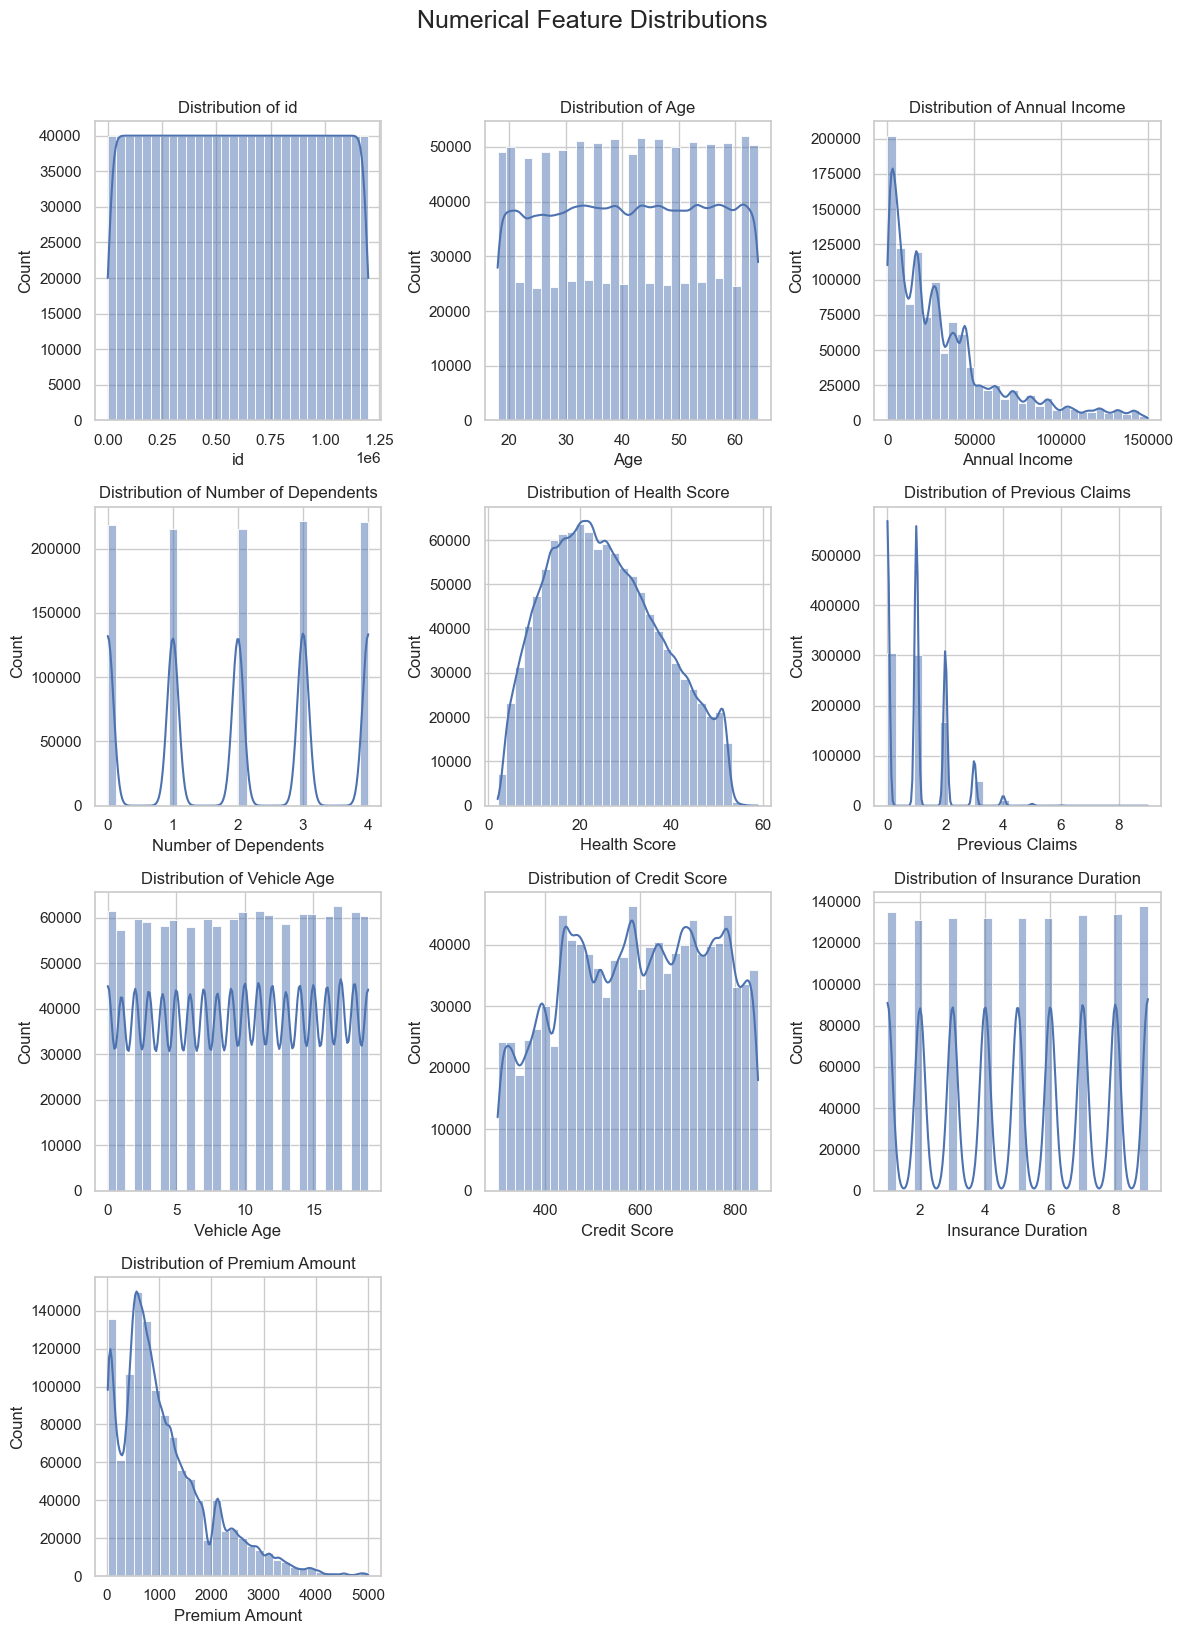

In [18]:
n_cols = 3
n_rows = math.ceil(len(numerical_vars) / n_cols)
plt.figure(figsize=(12, 4 * n_rows))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
fig.suptitle("Numerical Feature Distributions", fontsize=18, y=1.02)
axes = axes.flatten()
for i, col in enumerate(numerical_vars):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])      

plt.tight_layout()
plt.show()

# **Missing value detection**

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean().sort_values(ascending=False))*100
pd.concat([missing, missing_pct], axis=1, keys=["missing","percent"])

,missing,percent
Previous Claims,364029,30.335750
Occupation,358075,29.839583
Credit Score,137882,11.490167
Number of Dependents,109672,9.139333
Customer Feedback,77824,6.485333
Health Score,74076,6.173000
Annual Income,44949,3.745750
Age,18705,1.558750
Marital Status,18529,1.544083
Vehicle Age,6,0.000500


In [5]:
# Fill numerical continuous
num_cols_continuous = [
    "Annual Income", "Health Score",
    "Previous Claims", "Vehicle Age",
    "Credit Score", "Insurance Duration"
]
for col in num_cols_continuous:
    df[col] = df[col].fillna(df[col].median())

# Drop few missing value row
df = df.dropna(subset=["Age"])
df = df.dropna(subset=["Marital Status"])

# Fill Number of Dependents
df["Number of Dependents"] = df["Number of Dependents"].fillna(df["Number of Dependents"].median())

# Occupation → frequency encoding
occ_freq = df["Occupation"].value_counts(normalize=True)
df["Occupation"] = df["Occupation"].map(occ_freq).fillna(0)

# Customer Feedback
if df["Customer Feedback"].dtype == "object":
    cf_freq = df["Customer Feedback"].value_counts(normalize=True)
    df["Customer Feedback"] = df["Customer Feedback"].map(cf_freq).fillna(0)
else:
    df["Customer Feedback"] = df["Customer Feedback"].fillna(df["Customer Feedback"].median())

# Convert date
df["Policy Start Date"] = pd.to_datetime(df["Policy Start Date"], errors="coerce")

# Drop ID from numeric
df = df.drop(columns=["id"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1163064 entries, 0 to 1199999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   Age                   1163064 non-null  float64       
 1   Gender                1163064 non-null  object        
 2   Annual Income         1163064 non-null  float64       
 3   Marital Status        1163064 non-null  object        
 4   Number of Dependents  1163064 non-null  float64       
 5   Education Level       1163064 non-null  object        
 6   Occupation            1163064 non-null  float64       
 7   Health Score          1163064 non-null  float64       
 8   Location              1163064 non-null  object        
 9   Policy Type           1163064 non-null  object        
 10  Previous Claims       1163064 non-null  float64       
 11  Vehicle Age           1163064 non-null  float64       
 12  Credit Score          1163064 non-null  float64

# **Outlier Detection Boxplots**

In [18]:
# Detect outliers using the IQR method
numeric_cols = df.select_dtypes(include=[np.number]).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
              (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers (per column):\n", outliers)

Number of outliers (per column):
 Age                         0
Annual Income           68053
Number of Dependents        0
Occupation                  0
Health Score                0
Previous Claims         59917
Vehicle Age                 0
Credit Score                0
Insurance Duration          0
Customer Feedback       75056
Premium Amount          47691
dtype: int64


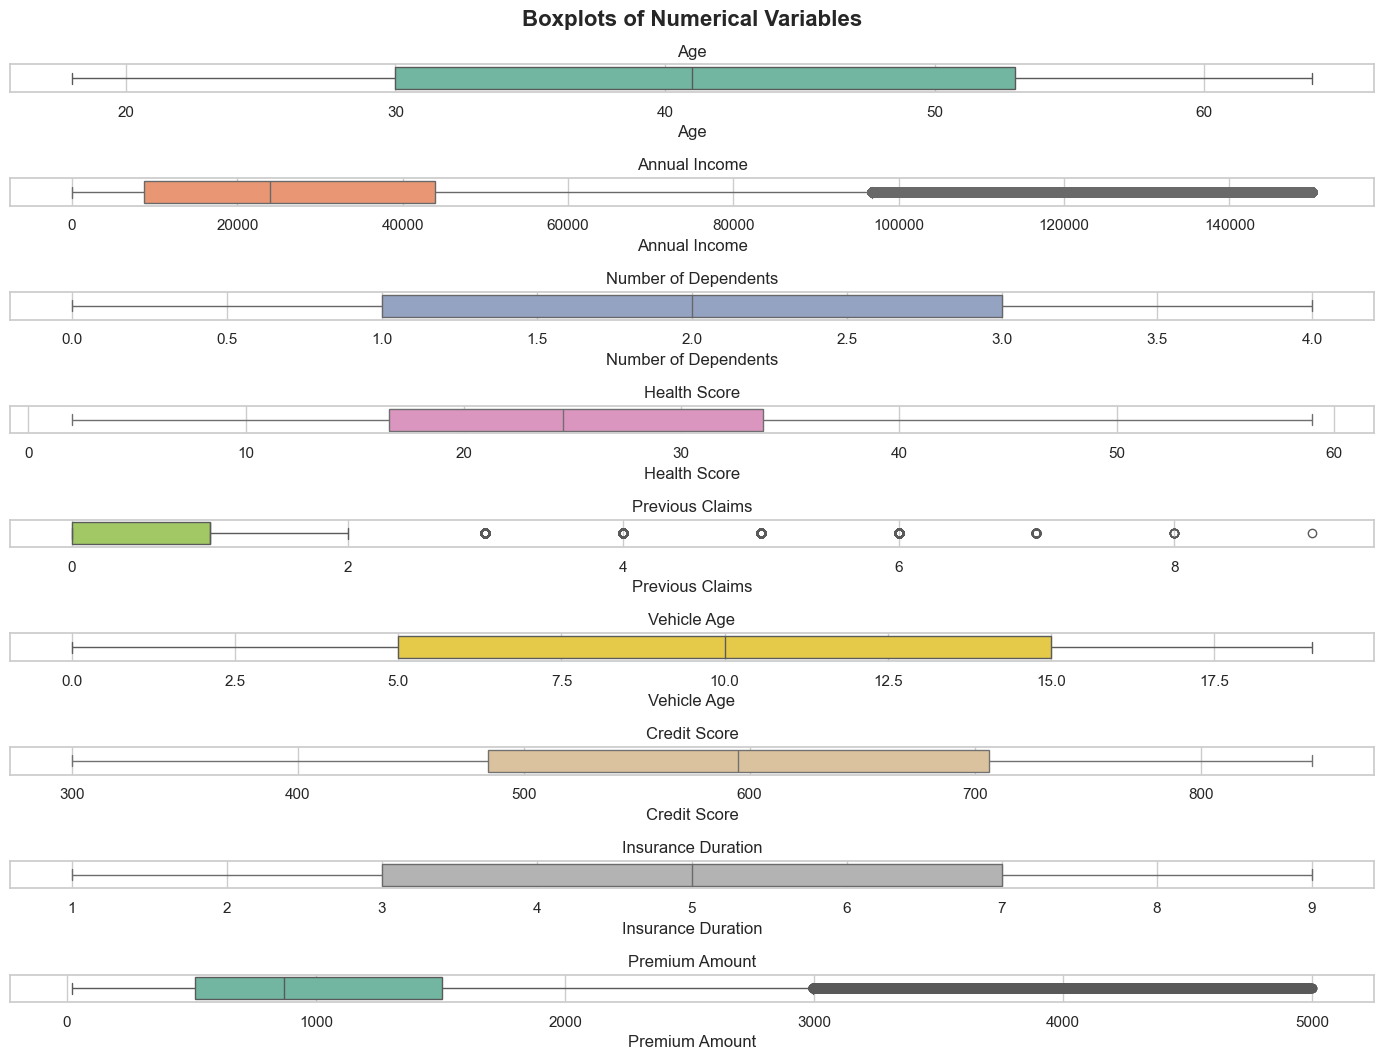

In [13]:
numeric_cols = [col for col in numerical_vars if col in df.columns]

palette = sns.color_palette("Set2", n_colors=len(numeric_cols))

n = len(numeric_cols)

plt.figure(figsize=(14, n * 1.2))
plt.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n, 1, i)
    sns.boxplot(
        x=df[col],
        orient='h',
        color=palette[i - 1]
    )
    plt.title(col)
    plt.tight_layout()

plt.show()


In [19]:
def classify_columns_by_outliers(df, numerical_vars, outlier_threshold=0.05):
    """
    Classify numerical columns into high-outlier and low-outlier groups
    """
    numeric_cols = [col for col in numerical_vars if col in df.columns]

    # IQR calculation
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1

    # Count outliers for each column based on IQR rule
    outlier_counts = (
        (df[numeric_cols] < (Q1 - 1.5 * IQR)) |
        (df[numeric_cols] > (Q3 + 1.5 * IQR))
    ).sum()

    outlier_ratios = outlier_counts / len(df)

    # Classify based on threshold
    high_outlier_cols = outlier_ratios[outlier_ratios > outlier_threshold].index.tolist()
    low_outlier_cols = outlier_ratios[outlier_ratios <= outlier_threshold].index.tolist()

    return high_outlier_cols, low_outlier_cols, outlier_ratios


# Call the function for your data 
high_outlier_cols, low_outlier_cols, outlier_ratios = classify_columns_by_outliers(
    df=df,
    numerical_vars=numerical_vars,
    outlier_threshold=0.05
)

print("Sort columns based on outliers")

print(f"\nColumns with many outliers (>5%):\n{high_outlier_cols}")

print(f"\nColumns with few outliers (<=5%):\n{low_outlier_cols}")
print("\nOutlier ratios (sorted):")
print(outlier_ratios.sort_values(ascending=False))


Sort columns based on outliers

Columns with many outliers (>5%):
['Annual Income', 'Previous Claims']

Columns with few outliers (<=5%):
['Age', 'Number of Dependents', 'Health Score', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'Premium Amount']

Outlier ratios (sorted):
Annual Income           0.058512
Previous Claims         0.051517
Premium Amount          0.041005
Age                     0.000000
Number of Dependents    0.000000
Health Score            0.000000
Vehicle Age             0.000000
Credit Score            0.000000
Insurance Duration      0.000000
dtype: float64


# **Categorical feature distribution**

In [ ]:
categorical_vars = [col for col in categorical_vars if col in df.columns]
numerical_vars = [col for col in numerical_vars if col in df.columns]

<Figure size 1200x2400 with 0 Axes>

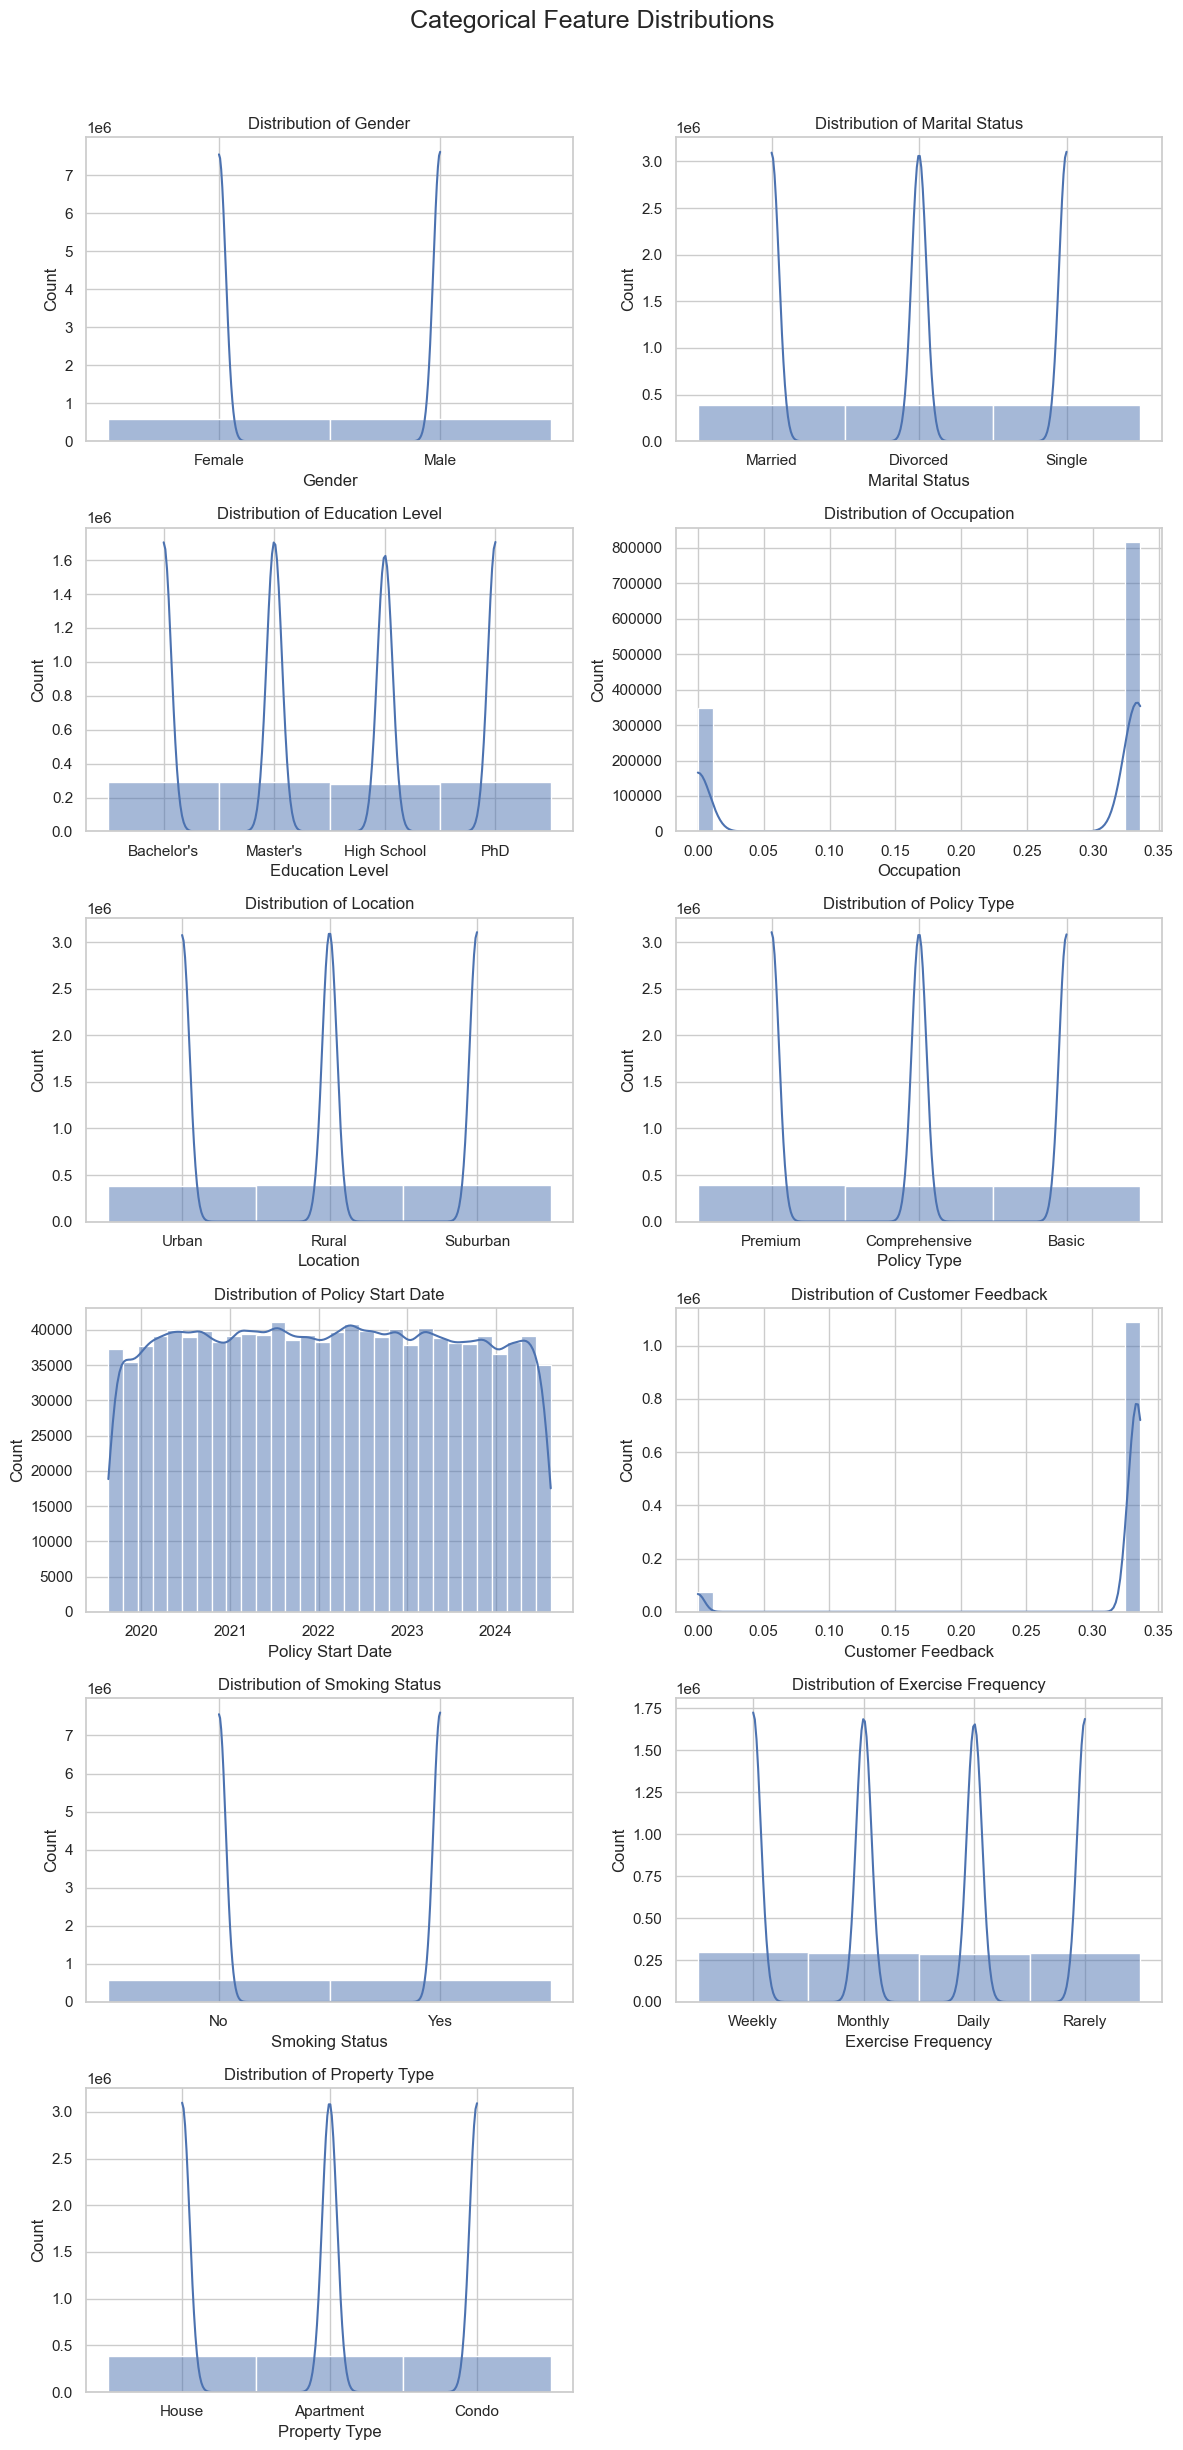

In [16]:
n_cols = 2
n_rows = math.ceil(len(categorical_vars) / n_cols)
plt.figure(figsize=(12, 4 * n_rows))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
fig.suptitle("Categorical Feature Distributions", fontsize=18, y=1.02)
axes = axes.flatten()
for i, col in enumerate(categorical_vars):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **Numerical feature distribution**

<Figure size 1200x2000 with 0 Axes>

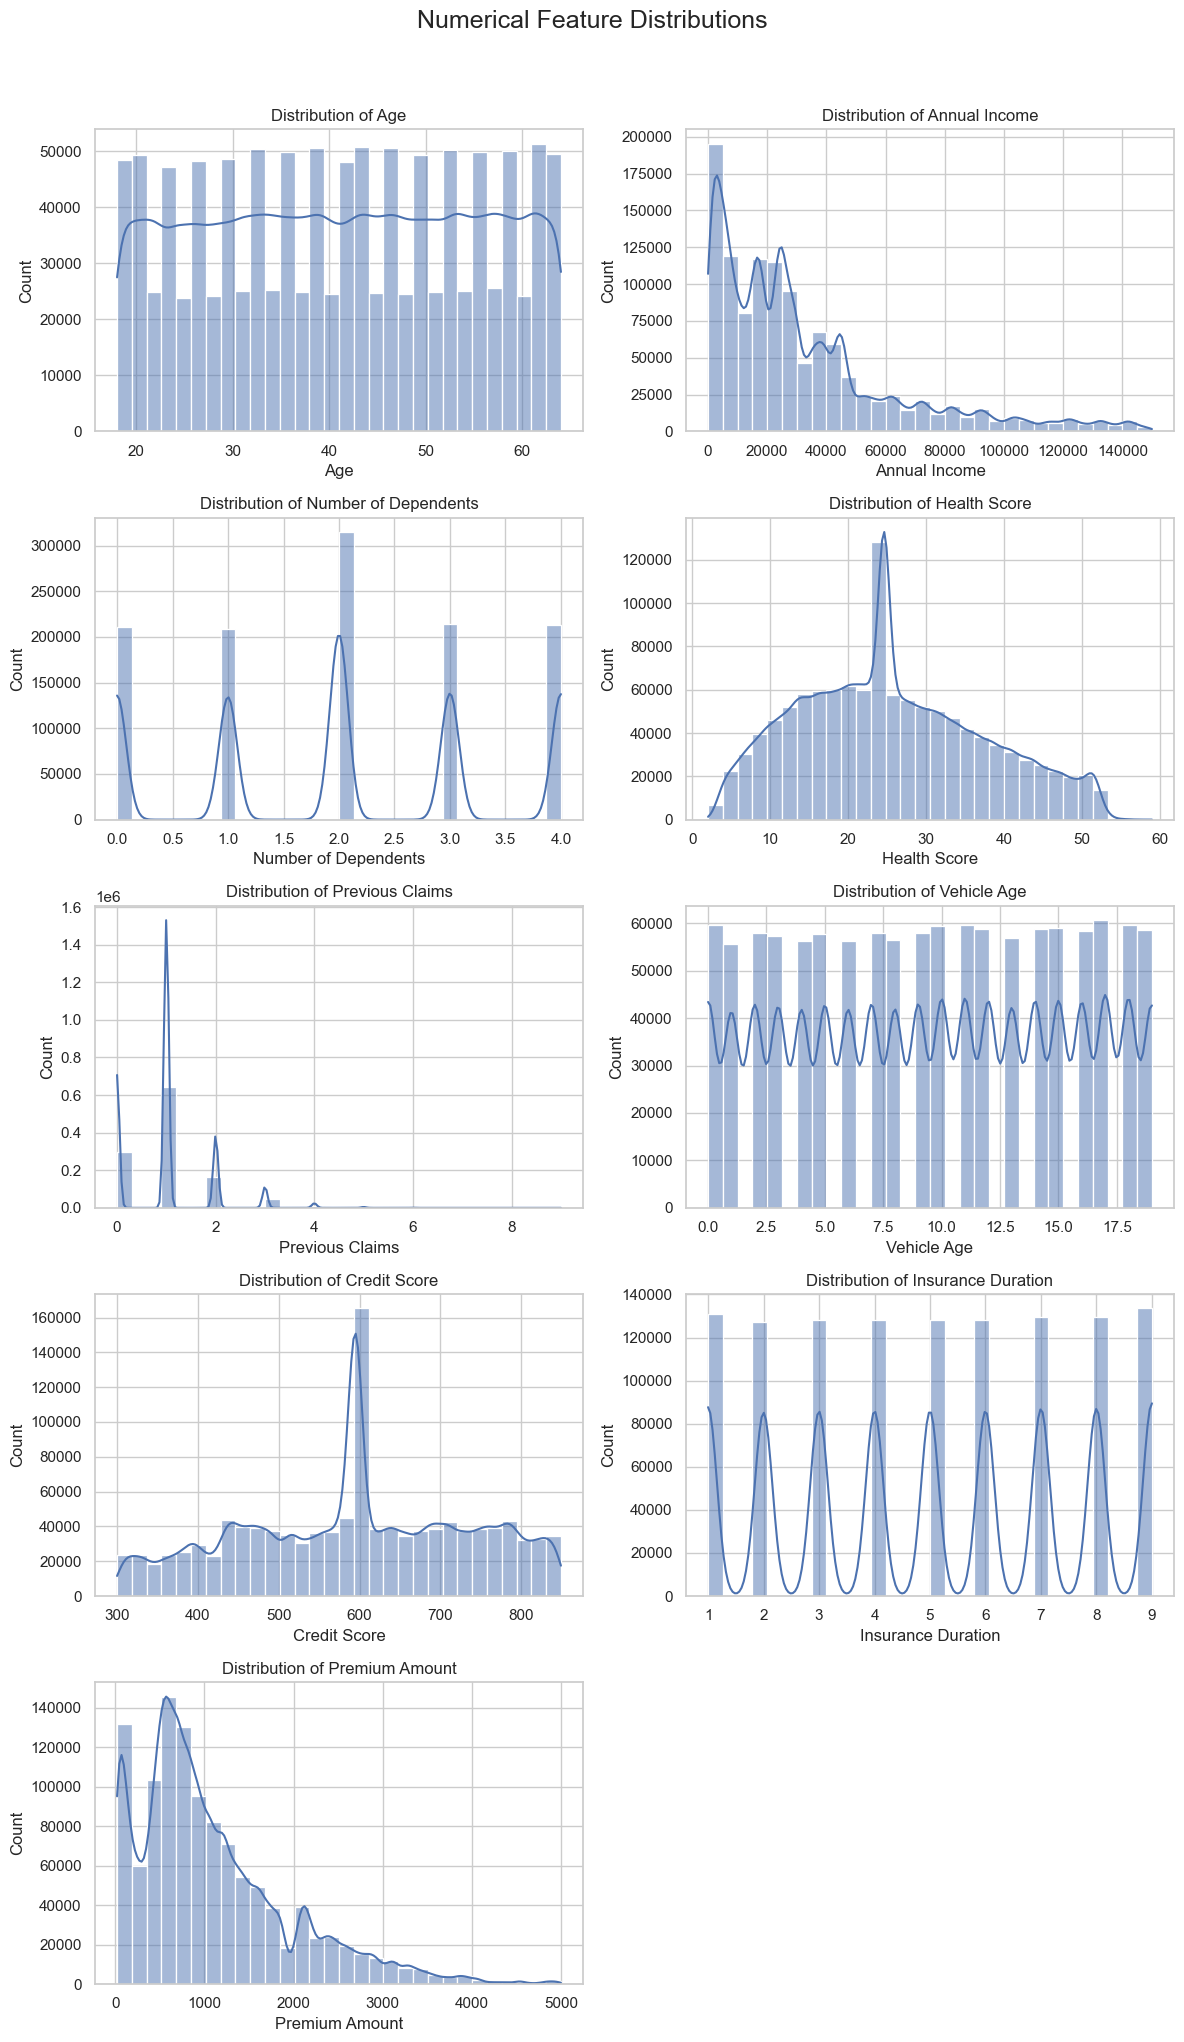

In [17]:
n_cols = 2
n_rows = math.ceil(len(numerical_vars) / n_cols)
plt.figure(figsize=(12, 4 * n_rows))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
fig.suptitle("Numerical Feature Distributions", fontsize=18, y=1.02)
axes = axes.flatten()
for i, col in enumerate(numerical_vars):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()